## Huffman Coding
Huffman coding is an algorithm used for lossless data compresssion. Huffman coding is also used as a component in many different comopression algorithms. It is used as a component in lossless compressions such as zip, gzip and png, and even as part of lossy compression algorithms like mp3 and jpeg.

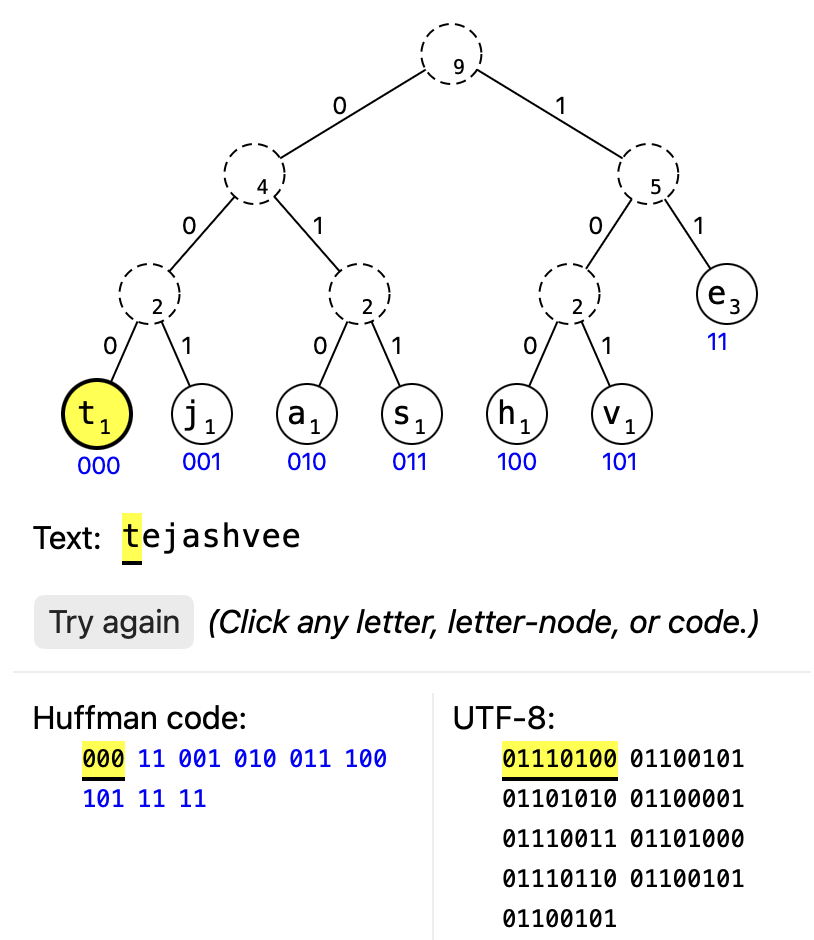

The picture above shows how the letters in a text are normally stored using UTF-8 and how Huffman coding makes it possible to store the same text with fewer bits.

**How it works?**
1. Count how often each piece of data occurs.
2. Build a binary tree, starting with the nodes with the lowest count. The new parent node has the combined count of its child nodes.
3. The edge from a parent gets '0' for the left child and '1' for the edge to the right child.
4. If the finished binary tree, follow the edges from the root node, adding '0' or '1' for each branch, to find the new huffman code for eeach piece of data.
5. Create the huffman code by converting the data, piece-by-piece into a binary code using the binary tree.

Huffman coding uses a variable length of bits to represent each piece of data, with a shorter bit representation for the pieces of data that occurs more often.

Furthermore, Huffman coding ensures that no code is the prefix of another code, which makes the compressed data easy to decode.

**Data compression** is when the original data size is reduced, but the information is mostly or fully kept. Sound or music files are for example usually stored in a compressed format, roughly just 10% of the original data size, but with most of the information kept.

**Lossless** means that even after the data is compressed, all the information is still there. This means that for example a compressed text still has all the same letter and characters as the original.

**Lossy** is the other variant of data compression, where some of the original information is lost or sacrificed, so that the data can be compressesd even more. Music, images, and video are normally stored and streamed with lossy compression like mp3, jpeg and mp4.

### Creating a huffman code manually
To get a better understanding of how Huffman Coding works, let's create a Huffman code manually, using the same text as in the animation: 'lossless'.

A text is normally stored in the computer using UTF-8, which means that each letter is stored using 8-bits for normal latin letters, like we have in 'lossless'. Other letters or symbols such as € or 🦄 are stored using more bits.

To compress the text "lossless" using huffman coding, we start by counting each letter.
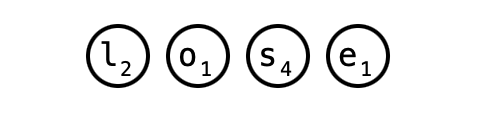
It can be seen that, in the nodes  above 👆, 's' occurs 4 times,'l' occurs 2 times and 'o' and 'e' occur just 1 time each.

We start building the tree with the least occurring letters 'o' and 'e' and their parent node gets count '2', because the counts for letter 'o' and 'e' are summarised.
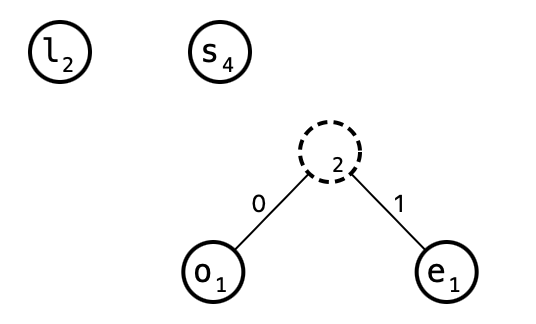

The next nodes that get a new parent node, are the nodes with the lowest count: "L" and the parent node of "o" and "e".
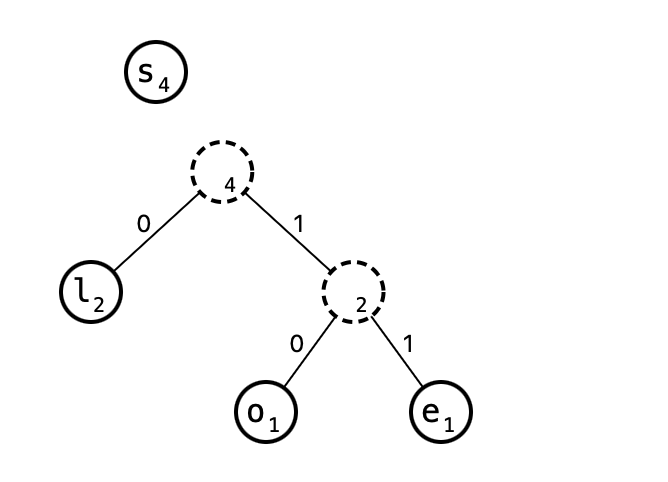

Now the last node 's' must be added to the binary tree. Letter node 's' and the parent node with count '4' get a new parent node with count '8'.
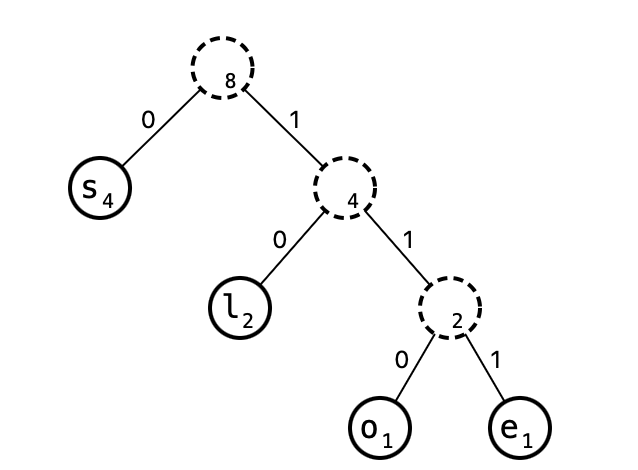

Following the edges from the root node, we can now determine the Huffman code for each letter in the word 'lossless'.
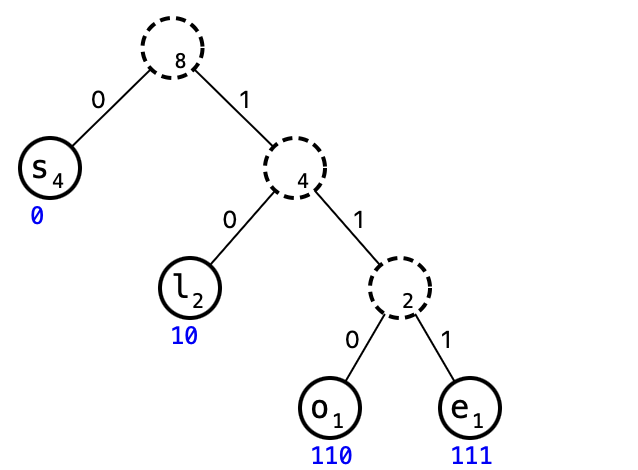
The huffman code for each letter can now be found under each letter node in the image above. A good thing about huffman coding is that the most used data pieces get the shortest code, so just '0' is the code for the letter 's'.

As mentioned earlier, such normal latin letters are usually stored with UTF-8, which means they take up 8 bits each. 

For example, the letter 'o' is stored as '01101111' with UTF-8, but it is stored as '110' with our huffman code for the word 'lossless'.

**With the UTF-8, a letter has always the same binary code, but with the Huffman code, the binary code for each letter (piece of data) changes with text(data set) we are compressing**

To summarise...
We have now compressed the word lossless from its UTF-8 code, **01101100 01101111 01110011 01110011 01101100 01100101 01110011 01110011** to just **10 110 0 0 10 111 0 0** using huffman coding.

## Decoding the huffman code
Just like with code stored as UTF-8, which our computers can already decode to the correct letters, the computer needs to know which bits represent which bits represent which piece of data in the huffman code. 

So along with a huffman code, there must also be a conversion table with information about what the human binary code is for each piece of data so that it can be decoded.

Taking this huffman code, 100110110 , and using the conversion table below:
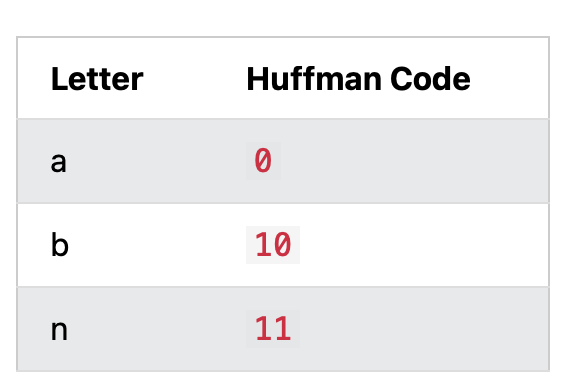

**How it works:**
1. Start from the left in the huffman code, and look up each bit sequence in the table
2. Match each code to the corresponding letter
3. Continue until the entire Huffman code is decoded.
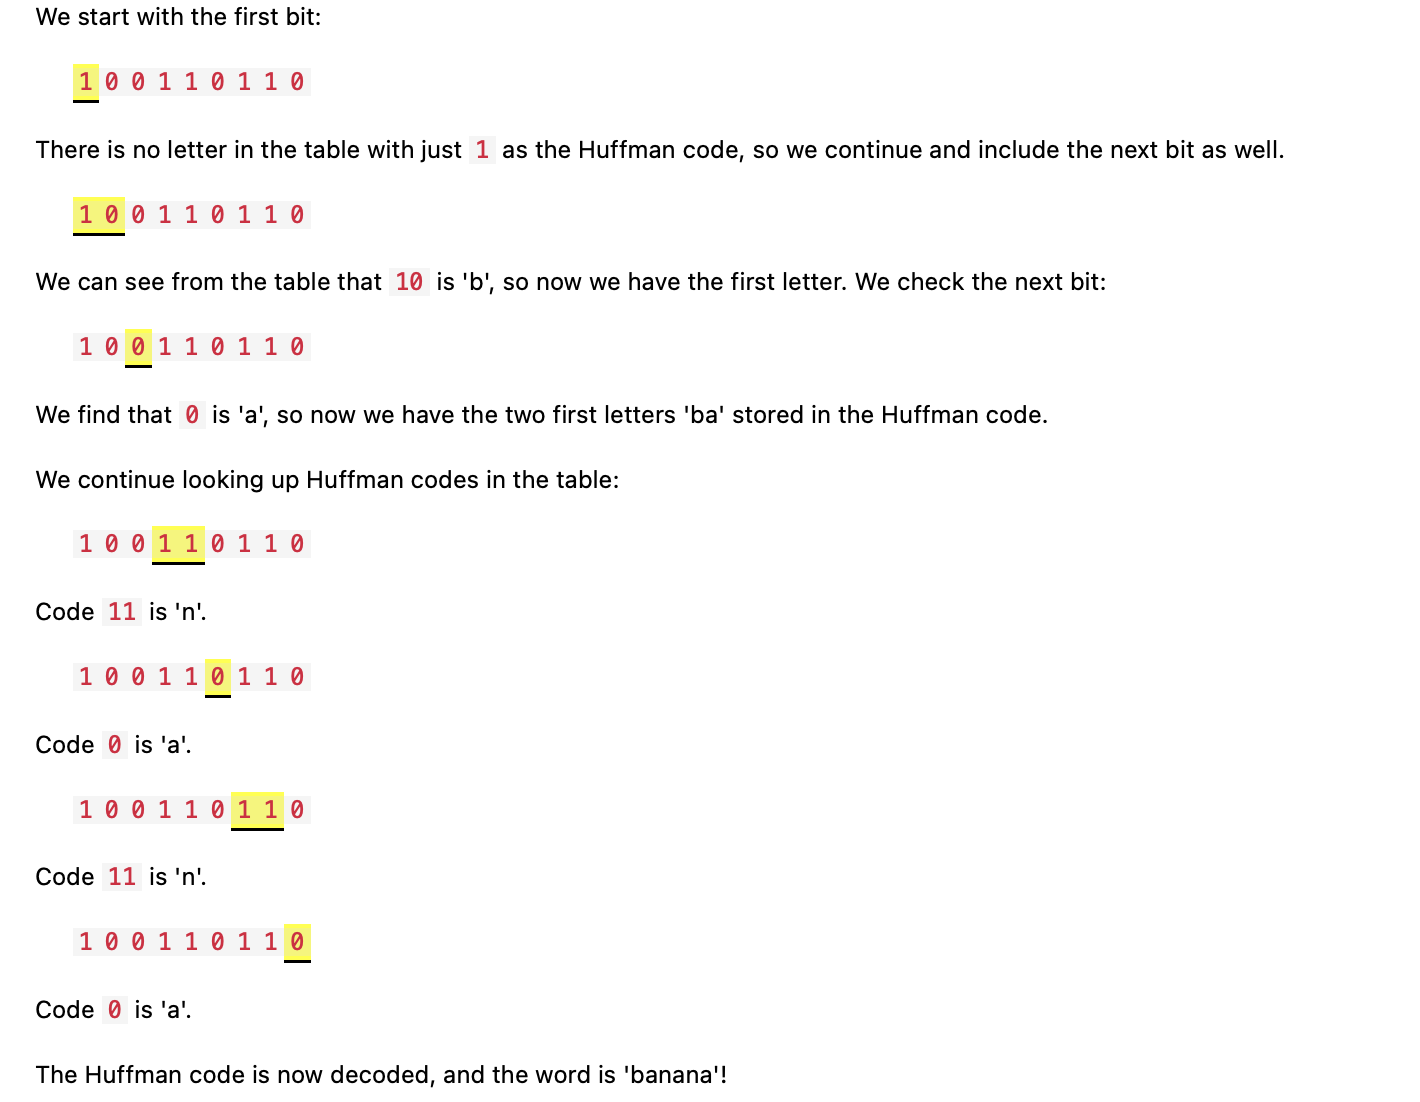

## Huffman Coding implementation
The correct word for creating Huffman code based on data or text is "encoding", and the opposite would be "decoding", when the original data or text is recreated based on the code.

The code example below takes a word, or any text really, and compress it using Huffman Coding.

In [1]:
class Node:
    def __init__(self, char=None, freq=0):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

nodes = []

def calculate_frequencies(word):
    frequencies = {}
    for char in word:
        if char not in frequencies:
            freq = word.count(char)
            frequencies[char] = freq
            nodes.append(Node(char, freq))

def build_huffman_tree():
    while len(nodes) > 1:
        nodes.sort(key=lambda x: x.freq)
        left = nodes.pop(0)
        right = nodes.pop(0)
        
        merged = Node(freq=left.freq + right.freq)
        merged.left = left
        merged.right = right
        
        nodes.append(merged)

    return nodes[0]

def generate_huffman_codes(node, current_code, codes):
    if node is None:
        return

    if node.char is not None:
        codes[node.char] = current_code

    generate_huffman_codes(node.left, current_code + '0', codes)
    generate_huffman_codes(node.right, current_code + '1', codes)

def huffman_encoding(word):
    global nodes
    nodes = []
    calculate_frequencies(word)
    root = build_huffman_tree()
    codes = {}
    generate_huffman_codes(root, '', codes)
    return codes

word = "lossless"
codes = huffman_encoding(word)
encoded_word = ''.join(codes[char] for char in word)

print("Word:", word)
print("Huffman code:", encoded_word)
print("Conversion table:", codes)

Word: lossless
Huffman code: 10110001011100
Conversion table: {'s': '0', 'l': '10', 'o': '110', 'e': '111'}


## Huffman Decoding Implementation
In addition to encode data using huffman coding, we should also have a way to decode it, to recreate the original information.

The implementation below is basically the same as the previous code example, but with an additional function for decoding the Huffman code.

The huffman_decoding function takes the Huffman code, and the codes Python dictionary (a heshmap) with the characters and their corresponding binary codes. 

The function then reverses the mapping, and checks the Huffman code bit-by-bit to recreate the original text.

In [2]:
class Node:
    def __init__(self, char=None, freq=0):
        self.char = char
        self.freq = freq
        self.left = None
        self.right = None

nodes = []

def calculate_frequencies(word):
    frequencies = {}
    for char in word:
        if char not in frequencies:
            freq = word.count(char)
            frequencies[char] = freq
            nodes.append(Node(char, freq))

def build_huffman_tree():
    while len(nodes) > 1:
        nodes.sort(key=lambda x: x.freq)
        left = nodes.pop(0)
        right = nodes.pop(0)
        
        merged = Node(freq=left.freq + right.freq)
        merged.left = left
        merged.right = right
        
        nodes.append(merged)

    return nodes[0]

def generate_huffman_codes(node, current_code, codes):
    if node is None:
        return

    if node.char is not None:
        codes[node.char] = current_code

    generate_huffman_codes(node.left, current_code + '0', codes)
    generate_huffman_codes(node.right, current_code + '1', codes)

def huffman_encoding(word):
    global nodes
    nodes = []
    calculate_frequencies(word)
    root = build_huffman_tree()
    codes = {}
    generate_huffman_codes(root, '', codes)
    return codes

def huffman_decoding(encoded_word, codes):
    current_code = ''
    decoded_chars = []

    # Invert the codes dictionary to get the reverse mapping
    code_to_char = {v: k for k, v in codes.items()}

    for bit in encoded_word:
        current_code += bit
        if current_code in code_to_char:
            decoded_chars.append(code_to_char[current_code])
            current_code = ''

    return ''.join(decoded_chars)

word = "lossless"
codes = huffman_encoding(word)
encoded_word = ''.join(codes[char] for char in word)
decoded_word = huffman_decoding(encoded_word, codes)

print("Initial word:", word)
print("Huffman code:", encoded_word)
print("Conversion table:", codes)
print("Decoded word:", decoded_word)

Initial word: lossless
Huffman code: 10110001011100
Conversion table: {'s': '0', 'l': '10', 'o': '110', 'e': '111'}
Decoded word: lossless


Note: Huffman Coding can be used for lossless compression of any kind of data, not just text. Huffman Coding is also used as a component in other compression algorithms like zip, and even in lossy compressions like jpeg and mp3.   